In [1]:
import sys
print(f"Success! Using Environment: {sys.prefix}")

Success! Using Environment: /home/sagemaker-user/Language-Translation/mnit_env


In [2]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [3]:
import torch
import pickle
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


import os
import re
import shutil
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gc
import gensim.downloader as api
from collections import Counter

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [5]:
import dagshub
import mlflow
dagshub.init(repo_owner='thanwal', repo_name='Language-Translation', mlflow=True)

/home/sagemaker-user/Language-Translation/mnit_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Accessing as thanwal

Initialized MLflow to track repo "thanwal/Language-Translation"

Repository thanwal/Language-Translation initialized!

Load Dataset from drive or upload to drive re-run

In [6]:
df = pd.read_csv('data/Cleaned_Sentence_pairs_Full.csv')
print(df.head())

                                    English  \
0                          muiriel is now .   
1                          muiriel is now .   
2  education in this world disappoints me .   
3                        that wont happen .   
4                              i miss you .   

                                          Hindi  
0             म्यूरियल अब बीस साल की हो गई है ।  
1                   म्यूरियल अब बीस साल की है ।  
2  मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ ।  
3                              वैसा नहीं होगा ।  
4                 मुझें तुम्हारी याद आ रही है ।  


In [7]:
def tokenize(text):
    return text.split()

special_tokens = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']
MIN_FREQ = 1
embedding_dim = 300

Function to create English embeddings

In [8]:
def create_English_embedding(df):
    English_train = df['English']
    English_word2vec = api.load('word2vec-google-news-300')

    English_train_sentences = [tokenize(x) for x in English_train]
    print(len(English_train_sentences))

    English_counter = Counter()
    for s in English_train_sentences:
        English_counter.update(s)

    English_valid_words = [w for w, count in English_counter.most_common() if count >= MIN_FREQ]

    English_word2idx = {tok: idx for idx, tok in enumerate(special_tokens)}
    for word in English_valid_words:
        English_word2idx[word] = len(English_word2idx)

    English_idx2word = {idx: word for word, idx in English_word2idx.items()}

    English_embedding_matrix = [np.zeros(embedding_dim), 
                                np.random.normal(scale=0.6, size=(embedding_dim,)),
                                np.zeros(embedding_dim),
                                np.zeros(embedding_dim)]

    for word in English_valid_words:
        if word in English_word2vec:
            English_embedding_matrix.append(English_word2vec[word])
        else:
            English_embedding_matrix.append(np.random.normal(scale=0.6, size=(embedding_dim,)))

    English_embedding_matrix = torch.from_numpy(np.array(English_embedding_matrix)).float()

    if len(English_embedding_matrix) == len(English_word2idx) == len(English_idx2word):
        print(len(English_word2idx))
        print(English_embedding_matrix.shape)

    del English_word2vec 
    gc.collect()

    return English_embedding_matrix, English_word2idx, English_idx2word

Function to create Hindi embeddings

In [9]:
def create_Hindi_embedding(df):
    Hindi_train = df['Hindi']
    Hindi_word2vec = api.load('fasttext-wiki-news-subwords-300')
    
    Hindi_train_sentences = [tokenize(x) for x in Hindi_train]
    print(len(Hindi_train_sentences))

    Hindi_counter = Counter()

    for s in Hindi_train_sentences:
        Hindi_counter.update(s)

    Hindi_valid_words = [w for w, count in Hindi_counter.most_common() if count >= MIN_FREQ]

    Hindi_word2idx={tok: idx for idx, tok in enumerate(special_tokens)}
    for word in Hindi_valid_words:
        Hindi_word2idx[word] = len(Hindi_word2idx)

    Hindi_idx2word = {idx: word for word, idx in Hindi_word2idx.items()}

    Hindi_embedding_matrix = [np.zeros(embedding_dim),
                            np.random.normal(scale=0.6, size=(embedding_dim,)),
                            np.zeros(embedding_dim),
                            np.zeros(embedding_dim)]

    for word in Hindi_valid_words:
        if word in Hindi_word2vec:
            Hindi_embedding_matrix.append(Hindi_word2vec[word])
        else:
            Hindi_embedding_matrix.append(np.random.normal(scale=0.6, size=(embedding_dim,)))

    Hindi_embedding_matrix = torch.from_numpy(np.array(Hindi_embedding_matrix)).float()

    if len(Hindi_embedding_matrix)==len(Hindi_word2idx)==len(Hindi_idx2word):
        print(len(Hindi_word2idx))
        print(Hindi_embedding_matrix.shape)

    del Hindi_word2vec 
    gc.collect()

    return Hindi_embedding_matrix, Hindi_word2idx, Hindi_idx2word

Load saved Ebedding or create and save for re-run to drive 

In [10]:
saves_path = 'saves'
if os.path.exists(saves_path):
    English_embedding_matrix = torch.load(os.path.join(saves_path, 'eng_emb.pt'))
    Hindi_embedding_matrix = torch.load(os.path.join(saves_path, 'hin_emb.pt'))

    with open(os.path.join(saves_path, 'eng_word2idx.pkl'), 'rb') as f:
        English_word2idx = pickle.load(f)

    with open(os.path.join(saves_path, 'hin_word2idx.pkl'), 'rb') as f:
        Hindi_word2idx = pickle.load(f)

    with open(os.path.join(saves_path, 'eng_idx2word.pkl'), 'rb') as f:
        English_idx2word = pickle.load(f)

    with open(os.path.join(saves_path, 'hin_idx2word.pkl'), 'rb') as f:
        Hindi_idx2word = pickle.load(f)

    print("All files loaded successfully from local directory.")

else:
    # Creation logic (assuming df and creation functions are defined elsewhere)
    English_embedding_matrix, English_word2idx, English_idx2word = create_English_embedding(df)
    Hindi_embedding_matrix, Hindi_word2idx, Hindi_idx2word = create_Hindi_embedding(df)

    # Create the folder locally if it doesn't exist
    os.makedirs(saves_path, exist_ok=True)

    # Saving logic
    torch.save(English_embedding_matrix, os.path.join(saves_path, 'eng_emb.pt'))
    torch.save(Hindi_embedding_matrix, os.path.join(saves_path, 'hin_emb.pt'))

    with open(os.path.join(saves_path, 'eng_word2idx.pkl'), 'wb') as f:
        pickle.dump(English_word2idx, f)

    with open(os.path.join(saves_path, 'hin_word2idx.pkl'), 'wb') as f:
        pickle.dump(Hindi_word2idx, f)

    with open(os.path.join(saves_path, 'eng_idx2word.pkl'), 'wb') as f:
        pickle.dump(English_idx2word, f)

    with open(os.path.join(saves_path, 'hin_idx2word.pkl'), 'wb') as f:
        pickle.dump(Hindi_idx2word, f)

    print(f"All files saved successfully to: {os.path.abspath(saves_path)}")

13747
5301
torch.Size([5301, 300])
13747
7068
torch.Size([7068, 300])
All files saved successfully to: /home/sagemaker-user/Language-Translation/saves


Split data into Train, Test, Val

In [11]:
df_train_val, df_test = train_test_split(df, test_size=0.10, random_state=42)
df_train, df_val = train_test_split(df_train_val, test_size=0.2, random_state=42)

finding max lenght for data sample

99% of English sentences are shorter than: 28.0
99% of Hindi sentences are shorter than: 28.0


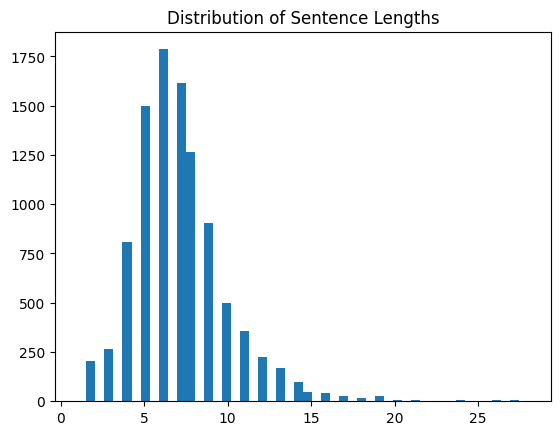

Max Len is 30.0


In [24]:
English_train = df_train['English']
English_train = df_train['Hindi']

eng_lengths = [len(tokenize(s)) for s in English_train]
hin_lengths = [len(tokenize(s)) for s in English_train]


max_len=max(np.percentile(eng_lengths, 100),np.percentile(hin_lengths, 100))+2

print(f"99% of English sentences are shorter than: {np.percentile(eng_lengths, 100)}")
print(f"99% of Hindi sentences are shorter than: {np.percentile(hin_lengths, 100)}")

plt.hist(eng_lengths, bins=50)
plt.title("Distribution of Sentence Lengths")
plt.show()

print(f"Max Len is {max_len}")

Create custom dataset

In [13]:
class TranslationDataset(Dataset):
    def __init__(self, df, English_word2idx, Hindi_word2idx, max_len=20):
        self.df = df
        self.English_word2idx = English_word2idx
        self.Hind_word2idx = Hindi_word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def preprocess(self, text, word2idx):
        tokens = tokenize(text)
        indices = [word2idx.get(tok, 1) for tok in tokens]
        indices = [2] + indices + [3]

        if len(indices) < self.max_len:
            indices += [0] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        return torch.tensor(indices, dtype=torch.long)

    def __getitem__(self, idx):
        english_text = self.df.iloc[idx]['English']
        hindi_text = self.df.iloc[idx]['Hindi']

        English_tensor = self.preprocess(english_text, self.English_word2idx)
        Hindi_tensor = self.preprocess(hindi_text, self.Hind_word2idx)

        return English_tensor, Hindi_tensor

Loading data into DataLoaders

In [ ]:
BATCH_SIZE=256

train_dataset = TranslationDataset(df_train, English_word2idx, Hindi_word2idx, max_len)
val_dataset = TranslationDataset(df_val, English_word2idx, Hindi_word2idx, max_len)
test_dataset = TranslationDataset(df_test, English_word2idx, Hindi_word2idx, max_len)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Varifying that DataLoader and Custom dataset is working fine

In [15]:
English_batch, Hindi_batch = next(iter(train_loader))

print(f"English Batch Shape: {English_batch.shape}")
print(f"Hindi Batch Shape: {Hindi_batch.shape}")

first_sentence = English_batch[0].tolist()
decoded = [English_idx2word.get(idx, '<UNK>') for idx in first_sentence]
print("\nFirst English Sentence in Batch:")
print(" ".join(decoded))

English Batch Shape: torch.Size([256, 7])
Hindi Batch Shape: torch.Size([256, 7])

First English Sentence in Batch:
<SOS> they like muslims . <EOS> <PAD>


Encoder Unit

In [16]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, pretrained_embeddings):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.dropout= nn.Dropout(dropout)

    def forward(self, English_batch):
        embedded = self.dropout(self.embedding(English_batch))
        
        outputs, (hidden, cell) = self.lstm(embedded)

        return hidden, cell

Decoder

In [17]:
class Decoder(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, num_layers, dropout, pretrained_embeddings):
        super().__init__()

        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell):
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))
        
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.fc(output.squeeze(1))

        return prediction, hidden, cell



Seq2Seq Model

In [18]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        
        self.encoder = encoder 
        self.decoder = decoder
        self.device = device

    def forward(self, English_batch, Hindi_batch, tfr=0.5):
        batch_size = English_batch.shape[0]
        Hindi_len = Hindi_batch.shape[1]
        Hindi_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, Hindi_len, Hindi_vocab_size).to(self.device)
        
        hidden, cell = self.encoder(English_batch)
        
        input = Hindi_batch[:, 0]

        for t in range(1, Hindi_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t, :] = output
            
            teacher_force = random.random() < tfr
            top_1 = output.argmax(1) 
            input = Hindi_batch[:, t] if teacher_force else top_1

        return outputs

In [19]:
def calculate_accuracy(preds, y, pad_idx):
    top_preds = preds.argmax(1, keepdim=True).squeeze(1)
    
    correct = top_preds.eq(y)
    
    mask = (y != pad_idx)
    correct = correct & mask
    
    accuracy = correct.sum().float() / mask.sum().float()
    return accuracy

In [20]:
def evaluate(model, val_loader, criterion):
    model.eval() 
    epoch_loss = 0
    epoch_acc = 0
    
    with torch.no_grad(): 
        for English_batch, Hindi_batch in val_loader:
            English_batch, Hindi_batch = English_batch.to(device), Hindi_batch.to(device)
            
            output = model(English_batch, Hindi_batch, 0) 
            
            output_dim = output.shape[-1]
            output = output[:, 1:, :].reshape(-1, output_dim)
            Hindi_batch = Hindi_batch[:, 1:].reshape(-1)
            
            loss = criterion(output, Hindi_batch)
            acc = calculate_accuracy(output, Hindi_batch, 0)
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            
    return epoch_loss / len(val_loader), epoch_acc / len(val_loader)

Traning Loop

In [21]:
BATCH_SIZE = 256
hidden_dim = 256
num_layers = 2
dropout = 0.3
lr = 0.0005
epoches = 50
clip = 1

Hindi_vocab_size = len(Hindi_word2idx) 

encoder = Encoder(embedding_dim, hidden_dim, num_layers, dropout, English_embedding_matrix).to(device)
decoder = Decoder(embedding_dim, Hindi_vocab_size, hidden_dim, num_layers, dropout, Hindi_embedding_matrix).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

optimizer = optim.Adam(model.parameters(), lr)

criterion = nn.CrossEntropyLoss(ignore_index=0) 

mlflow.set_experiment("Language_Translation_LSTM_base")
with mlflow.start_run(run_name="LSTM_run_1_max_len_5"):
    
    mlflow.log_params({
        "epochs": epoches,
        "hidden_dim": hidden_dim,
        "num_layers": num_layers,
        "dropout": dropout,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": lr
    })

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(epoches):
        model.train()
        epoch_loss = 0.0
        epoch_acc = 0.0

        for English_batch, Hindi_batch in train_loader:
            English_batch, Hindi_batch = English_batch.to(device), Hindi_batch.to(device)

            optimizer.zero_grad()
            
            output = model(English_batch, Hindi_batch)

            output_dim = output.shape[-1]
            output = output[:, 1:, :].reshape(-1, output_dim)
            Hindi_batch = Hindi_batch[:, 1:].reshape(-1)

            loss = criterion(output, Hindi_batch)
            acc = calculate_accuracy(output, Hindi_batch, 0)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

        train_loss = epoch_loss / len(train_loader)
        train_acc = epoch_acc / len(train_loader)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        # GPU Memory Tracking
        gpu_peak_gb = 0.0
        if torch.cuda.is_available():
            gpu_peak_gb = torch.cuda.max_memory_allocated(device) / (1024**3)
            torch.cuda.reset_peak_memory_stats(device)

        mlflow.log_metrics({
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "gpu_peak_gb": gpu_peak_gb
        }, step=epoch)

        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"GPU Peak: {gpu_peak_gb:.2f}GB")

    with open("LSTM_model_architecture.txt", "w") as f:
        f.write(str(model))
    mlflow.log_artifact("LSTM_model_architecture.txt")
    mlflow.pytorch.log_model(model, "pytorch_model")

🏃 View run LSTM_run_1_max_len_5 at: https://dagshub.com/thanwal/Language-Translation.mlflow/#/experiments/2/runs/d5e244cfceca4fa59ea44b6ec5bb9422
🧪 View experiment at: https://dagshub.com/thanwal/Language-Translation.mlflow/#/experiments/2


KeyboardInterrupt: 

In [ ]:
def translate_sentence(sentence, model, English_word2idx, Hindi_idx2word, device, max_len=30):
    model.eval() 
    
    # 1. Tokenize English sentence
    if isinstance(sentence, str):
        # Assuming you have a tokenize() function defined above, otherwise use sentence.split()
        tokens = [word.lower() for word in sentence.split()]
    else:
        tokens = [word.lower() for word in sentence]
        
    # 2. Add <SOS> (2) and <EOS> (3)
    indices = [English_word2idx.get(tok, 1) for tok in tokens] # 1 is assumed to be <UNK>
    indices = [2] + indices + [3] 
    
    English_tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        # 3. CRITICAL FIX: Unpack BOTH hidden and cell states from the LSTM Encoder
        hidden, cell = model.encoder(English_tensor)
        
    Hindi_indexes = [2] # Start with <SOS>
    
    for i in range(max_len):
        trg_tensor = torch.tensor([Hindi_indexes[-1]], dtype=torch.long).to(device)
        
        with torch.no_grad():
            # 4. CRITICAL FIX: Pass BOTH hidden and cell states into the LSTM Decoder
            output, hidden, cell = model.decoder(trg_tensor, hidden, cell)
            
        pred_token = output.argmax(1).item()
        Hindi_indexes.append(pred_token)
        
        # Stop if <EOS> is predicted
        if pred_token == 3:
            break
            
    # 5. Convert indices back to words
    trg_tokens = [Hindi_idx2word.get(i, '<UNK>') for i in Hindi_indexes]
    
    # Return string, cutting off <SOS> and <EOS>
    return " ".join(trg_tokens[1:-1])




In [ ]:
test_indices = random.sample(range(len(df_test)), 10)

for idx in test_indices:
    src_sentence = df_test.iloc[idx]['English']
    true_translation = df_test.iloc[idx]['Hindi']
    
    model_prediction = translate_sentence(
        src_sentence, model, English_word2idx, Hindi_idx2word, device
    )
    
    print(f"English: {src_sentence}")
    print(f"Actual : {true_translation}")
    print(f"Model  : {model_prediction}")
    print("-" * 50)

English: I'm like you.
Actual : मैं आपके जैसा हूँ।
Model  : म म
--------------------------------------------------
English: Got it?
Actual : समझे कि नहीं?
Model  : म म
--------------------------------------------------
English: Hush!
Actual : चुप!
Model  : म म
--------------------------------------------------
English: Hello?
Actual : हैलो?
Model  : म म
--------------------------------------------------
English: I won!
Actual : मैं जीत गया!
Model  : म म
--------------------------------------------------
English: They're wrong.
Actual : वे गलत हैं।
Model  : म म
--------------------------------------------------
English: They're quiet.
Actual : वे शांत हैं।
Model  : म म
--------------------------------------------------
English: Quick!
Actual : जल्दी!
Model  : म म
--------------------------------------------------
English: I do not understand.
Actual : मैं समझा नहीं।
Model  : म म
--------------------------------------------------
English: Who is Tom?
Actual : टॉम कौन है?
Model  : म म
---